# 01B — Classification U-Net Mask Intervention QC

This notebook is a **small follow-up QC**, not another preprocessing pipeline.

Why it is needed:

The corrected classification preprocessing successfully restored all 38 classes and the full fixed stratified split, but the U-Net mask audit reported:

```text
Potential invalid masks: 346
Maximum foreground fraction: 1.0
```

These samples must be inspected before the leaf-only teacher and counterfactual student are trained.

The purpose is to distinguish:

1. genuinely full-frame leaf images, where a nearly/full foreground mask may be legitimate;
2. U-Net failures, where background exists but the model predicts almost the entire image as leaf.

**CPU is sufficient.**


# STEP 1 — Imports and PlantVillage Download

In [1]:
!pip -q install kagglehub

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import kagglehub

download_path = Path(
    kagglehub.dataset_download(
        "abdallahalidev/plantvillage-dataset"
    )
)

def find_dataset_root(base):
    required = {"color","grayscale","segmented"}
    candidates = [base] + [p for p in base.rglob("*") if p.is_dir()]
    for path in candidates:
        try:
            names = {p.name for p in path.iterdir() if p.is_dir()}
            if required.issubset(names):
                return path
        except PermissionError:
            pass
    return None

dataset_root = find_dataset_root(download_path)

assert dataset_root is not None

print("Dataset root:", dataset_root)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset root: /kaggle/input/plantvillage-dataset/plantvillage dataset


# STEP 2 — Mount Drive and Load Classification Artifacts

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PlantVillage_Classification"
)

MANIFEST_PATH = PROJECT_DIR/"final_classification_manifest_v2.csv"
MASK_ARCHIVE = PROJECT_DIR/"classification_unet_masks_packed.npz"
MASK_QC_PATH = PROJECT_DIR/"artifacts"/"classification_unet_mask_qc.csv"

for path in [MANIFEST_PATH,MASK_ARCHIVE,MASK_QC_PATH]:
    print("✅" if path.exists() else "❌", path)
    assert path.exists()

df = pd.read_csv(MANIFEST_PATH)
mask_qc = pd.read_csv(MASK_QC_PATH)

assert len(df) == 54304
assert len(mask_qc) == 54304

qc_df = df.merge(
    mask_qc[
        [
            "sample_id",
            "foreground_fraction",
            "potential_invalid"
        ]
    ],
    on="sample_id",
    how="left"
)

assert qc_df["foreground_fraction"].isna().sum() == 0

flagged_df = qc_df[
    qc_df["potential_invalid"] == True
].copy()

print("Total samples:", len(qc_df))
print("Flagged masks:", len(flagged_df))
print("Flagged percentage:", 100*len(flagged_df)/len(qc_df))


Mounted at /content/drive
✅ /content/drive/MyDrive/PlantVillage_Classification/final_classification_manifest_v2.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_unet_masks_packed.npz
✅ /content/drive/MyDrive/PlantVillage_Classification/artifacts/classification_unet_mask_qc.csv
Total samples: 54304
Flagged masks: 346
Flagged percentage: 0.6371538008249853


# STEP 3 — Understand Why They Were Flagged

In [3]:
print(
    flagged_df[
        "foreground_fraction"
    ].describe()
)

print("\nBy split:")
print(
    flagged_df[
        "split"
    ].value_counts()
)

print("\nTop flagged classes:")
display(
    flagged_df[
        "class"
    ]
    .value_counts()
    .head(20)
    .rename("flagged_count")
    .to_frame()
)

exact_full = (
    flagged_df[
        "foreground_fraction"
    ] >= 0.999999
).sum()

very_full = (
    flagged_df[
        "foreground_fraction"
    ] >= 0.999
).sum()

very_empty = (
    flagged_df[
        "foreground_fraction"
    ] <= 0.001
).sum()

print("\nExactly/full ~100%:", exact_full)
print(">=99.9% foreground:", very_full)
print("<=0.1% foreground:", very_empty)


count    346.000000
mean       0.999854
std        0.000252
min        0.999008
25%        0.999821
50%        1.000000
75%        1.000000
max        1.000000
Name: foreground_fraction, dtype: float64

By split:
split
train    274
test      40
val       32
Name: count, dtype: int64

Top flagged classes:


,flagged_count
class,
Corn_(maize)___healthy,343
Squash___Powdery_mildew,3



Exactly/full ~100%: 189
>=99.9% foreground: 346
<=0.1% foreground: 0


# STEP 4 — Load Packed Masks

In [4]:
with np.load(MASK_ARCHIVE) as data:
    mask_ids = data["sample_ids"].astype(str)
    packed_masks = data["packed_masks"]

mask_index = {
    sample_id:i
    for i,sample_id in enumerate(mask_ids)
}

def get_mask(sample_id):
    packed = packed_masks[
        mask_index[str(sample_id)]
    ]

    return np.unpackbits(
        packed
    )[:256*256].reshape(
        256,256
    ).astype(np.uint8)


# STEP 5 — Visualize Random Flagged Masks

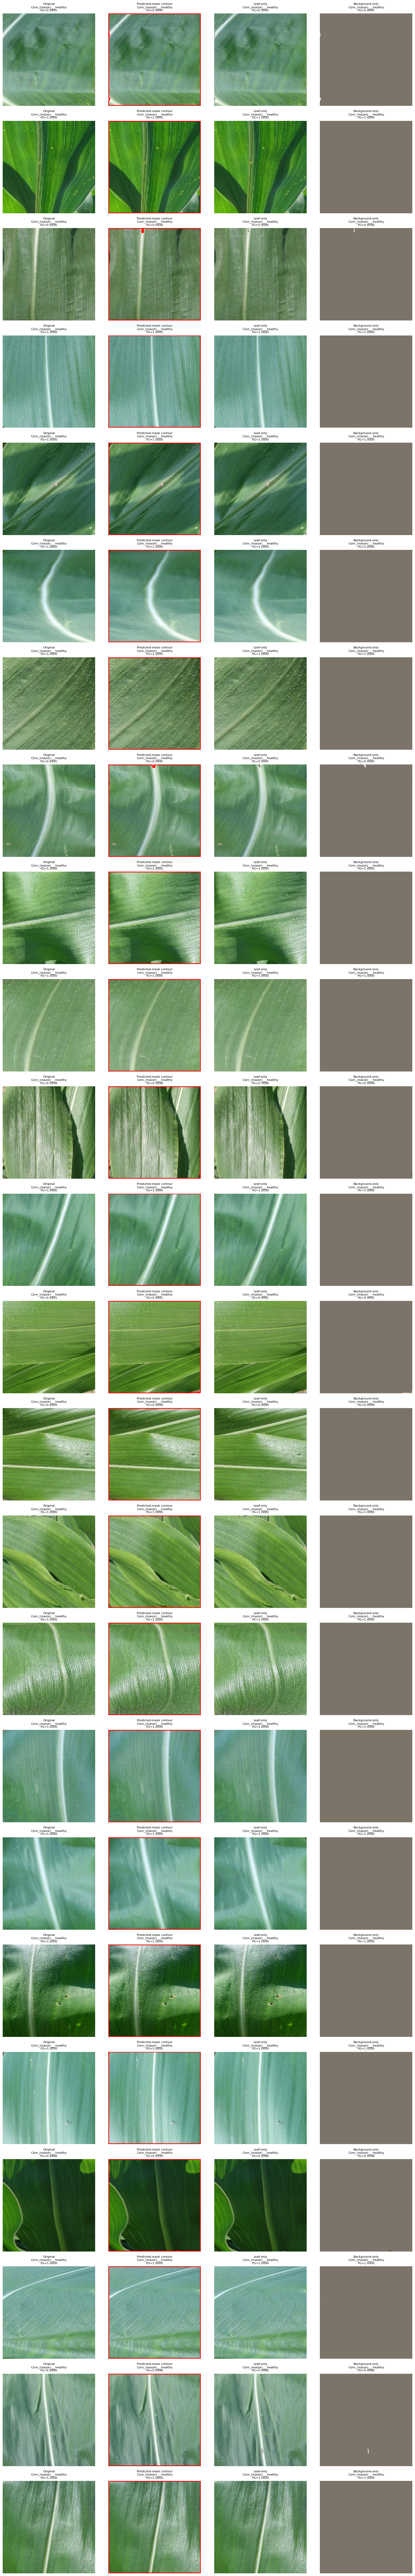

Saved: /content/drive/MyDrive/PlantVillage_Classification/visuals/flagged_unet_mask_qc_examples.png


In [5]:
RANDOM_SEED = 42

n = min(
    24,
    len(flagged_df)
)

preview = flagged_df.sample(
    n=n,
    random_state=RANDOM_SEED
).reset_index(drop=True)

fig,axes = plt.subplots(
    n,
    4,
    figsize=(16,4*n)
)

if n == 1:
    axes = np.array([axes])

neutral = np.array(
    [124,116,104],
    dtype=np.uint8
)

for r,row in preview.iterrows():

    image = np.array(
        Image.open(
            dataset_root/row["color_rel"]
        ).convert("RGB")
    )

    mask = get_mask(
        row["sample_id"]
    )

    if mask.shape != image.shape[:2]:
        mask_full = cv2.resize(
            mask,
            (image.shape[1],image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )
    else:
        mask_full = mask

    leaf_only = np.empty_like(image)
    leaf_only[:] = neutral
    leaf_only[mask_full==1] = image[mask_full==1]

    background_only = image.copy()
    background_only[mask_full==1] = neutral

    overlay = image.copy()
    contour_mask = (
        mask_full*255
    ).astype(np.uint8)

    contours,_ = cv2.findContours(
        contour_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        overlay,
        contours,
        -1,
        (255,0,0),
        2
    )

    views = [
        image,
        overlay,
        leaf_only,
        background_only
    ]

    titles = [
        "Original",
        "Predicted-mask contour",
        "Leaf-only",
        "Background-only"
    ]

    for c,(view,title) in enumerate(zip(views,titles)):
        axes[r,c].imshow(view)
        axes[r,c].set_title(
            f"{title}\n"
            f"{row['class']}\n"
            f"FG={row['foreground_fraction']:.4f}",
            fontsize=8
        )
        axes[r,c].axis("off")

plt.tight_layout()

QC_VISUAL = PROJECT_DIR/"visuals"/"flagged_unet_mask_qc_examples.png"

plt.savefig(
    QC_VISUAL,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print("Saved:", QC_VISUAL)


# STEP 6 — Create Compact Contact Sheets for All Flagged Samples

In [6]:
CONTACT_DIR = PROJECT_DIR/"visuals"/"flagged_mask_contact_sheets"
CONTACT_DIR.mkdir(parents=True,exist_ok=True)

PER_SHEET = 12

for start in range(
    0,
    len(flagged_df),
    PER_SHEET
):

    subset = flagged_df.iloc[
        start:start+PER_SHEET
    ].reset_index(drop=True)

    fig,axes = plt.subplots(
        3,
        4,
        figsize=(16,12)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for i,row in subset.iterrows():

        image = np.array(
            Image.open(
                dataset_root/row["color_rel"]
            ).convert("RGB")
        )

        mask = get_mask(
            row["sample_id"]
        )

        if mask.shape != image.shape[:2]:
            mask = cv2.resize(
                mask,
                (image.shape[1],image.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        overlay = image.copy()

        contours,_ = cv2.findContours(
            (mask*255).astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        cv2.drawContours(
            overlay,
            contours,
            -1,
            (255,0,0),
            2
        )

        axes[i].imshow(overlay)
        axes[i].set_title(
            f"{row['sample_id']}\n"
            f"{row['class']}\n"
            f"FG={row['foreground_fraction']:.4f}",
            fontsize=7
        )
        axes[i].axis("off")

    plt.tight_layout()

    out = CONTACT_DIR/f"flagged_masks_{start//PER_SHEET + 1:03d}.png"

    plt.savefig(
        out,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close()

print(
    "Contact sheets:",
    len(list(CONTACT_DIR.glob("*.png")))
)

print(
    "Saved in:",
    CONTACT_DIR
)


Contact sheets: 29
Saved in: /content/drive/MyDrive/PlantVillage_Classification/visuals/flagged_mask_contact_sheets


# What to send back

Please send:

1. the printed STEP 3 output;
2. `flagged_unet_mask_qc_examples.png`;
3. ideally the first 2–3 contact sheets.

Do **not** start the leaf-only teacher or proposed counterfactual model until these masks are reviewed.

The Standard RGB baseline itself does not depend on mask quality, but for a clean synchronized workflow it is better to finalize this QC first.
